# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

<table style="width:50%; font-size:12px; border-collapse: collapse; margin: 0 auto; text-align: left;">
  <thead>
    <tr style="background-color:#f2f2f2; text-align:left; color: black;">
      <th style="border:1px solid #ddd;">Attribute</th>
      <th style="border:1px solid #ddd;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="border:1px solid #ddd;">carID</td><td style="border:1px solid #ddd;">An attribute that contains an identifier for each car</td></tr>
    <tr><td style="border:1px solid #ddd;">Brand</td><td style="border:1px solid #ddd;">The car’s main brand (e.g. Ford, Toyota)</td></tr>
    <tr><td style="border:1px solid #ddd;">model</td><td style="border:1px solid #ddd;">The car model</td></tr>
    <tr><td style="border:1px solid #ddd;">year</td><td style="border:1px solid #ddd;">The year of Registration of the Car</td></tr>
    <tr><td style="border:1px solid #ddd;">mileage</td><td style="border:1px solid #ddd;">The total reported distance travelled by the car (in miles)</td></tr>
    <tr><td style="border:1px solid #ddd;">tax</td><td style="border:1px solid #ddd;">The amount of road tax (in £) that, in 2020, was applicable to the car in question.</td></tr>
    <tr><td style="border:1px solid #ddd;">fuelType</td><td style="border:1px solid #ddd;">Type of Fuel used by the car (Diesel, Petrol, Hybrid, Electric)</td></tr>
    <tr><td style="border:1px solid #ddd;">mpg</td><td style="border:1px solid #ddd;">Average Miles per Gallon</td></tr>
    <tr><td style="border:1px solid #ddd;">engineSize</td><td style="border:1px solid #ddd;">Size of Engine in liters (Cubic Decimeters)</td></tr>
    <tr><td style="border:1px solid #ddd;">paintQuality%</td><td style="border:1px solid #ddd;">The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation)</td></tr>
    <tr><td style="border:1px solid #ddd;">previousOwners</td><td style="border:1px solid #ddd;">Number of previous registered owners of the vehicle</td></tr>
    <tr><td style="border:1px solid #ddd;">hasDamage</td><td style="border:1px solid #ddd;">Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not</td></tr>
    <tr><td style="border:1px solid #ddd;">price</td><td style="border:1px solid #ddd;">The car’s price when purchased by Cars 4 You (in £)</td></tr>
  </tbody>
</table>


## Train

In [2]:
train_cars = pd.read_csv("project_data/train.csv")
print(f"The train dataset has {train_cars.shape[0]} rows and {train_cars.shape[1]} columns")

The train dataset has 75973 rows and 14 columns


In [3]:
train_cars.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


In [4]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [5]:
train_cars.columns

Index(['carID', 'Brand', 'model', 'year', 'price', 'transmission', 'mileage',
       'fuelType', 'tax', 'mpg', 'engineSize', 'paintQuality%',
       'previousOwners', 'hasDamage'],
      dtype='object')

In [6]:
train_cars.duplicated().sum()

0

In [7]:
train_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,74452,72,Ford,14808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,74456,735,Focus,6353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74482.0,NaN,NaN,NaN,2017.096611,2.208704,1970.0,2016.0,2017.0,2019.0,2024.121759
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,40,Manual,38050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74510.0,NaN,NaN,NaN,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.0
fuelType,74462,34,Petrol,37995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,68069.0,NaN,NaN,NaN,120.329078,65.521176,-91.12163,125.0,145.0,145.0,580.0
mpg,68047.0,NaN,NaN,NaN,55.152666,16.497837,-43.421768,46.3,54.3,62.8,470.8


In [8]:
train_cars.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

The train_cars dataset has null values in almost every column, this is a problem we will solve later on.

## Test

In [9]:
test_cars = pd.read_csv("project_data/test.csv")
print(f"The test dataset has {test_cars.shape[0]} rows and {test_cars.shape[1]} columns")

The test dataset has 32567 rows and 13 columns


In [10]:
test_cars.head()

,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0


In [11]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32567 entries, 0 to 32566
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           32567 non-null  int64  
 1   Brand           31918 non-null  object 
 2   model           31917 non-null  object 
 3   year            31914 non-null  float64
 4   transmission    31944 non-null  object 
 5   mileage         31878 non-null  float64
 6   fuelType        31911 non-null  object 
 7   tax             29259 non-null  float64
 8   mpg             29279 non-null  float64
 9   engineSize      31939 non-null  float64
 10  paintQuality%   31942 non-null  float64
 11  previousOwners  31970 non-null  float64
 12  hasDamage       31970 non-null  float64
dtypes: float64(8), int64(1), object(4)
memory usage: 3.2+ MB


In [12]:
test_cars.duplicated().sum()

0

In [13]:
test_cars.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,32567.0,NaN,NaN,NaN,92256.0,9401.427445,75973.0,84114.5,92256.0,100397.5,108539.0
Brand,31918,64,Ford,6360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,31917,593,Focus,2721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,31914.0,NaN,NaN,NaN,2017.102299,2.207969,1991.0,2016.0,2017.0,2019.0,2024.121759
transmission,31944,38,Manual,16312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,31878.0,NaN,NaN,NaN,22952.658921,22132.758713,-58540.574478,7298.25,17225.5,32500.0,279000.0
fuelType,31911,29,Petrol,16113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,29259.0,NaN,NaN,NaN,120.569239,65.56057,-91.12163,125.0,145.0,145.0,580.0
mpg,29279.0,NaN,NaN,NaN,55.210728,17.644635,-43.421768,46.3,54.3,62.8,470.8
engineSize,31939.0,NaN,NaN,NaN,1.665377,0.574467,-0.103493,1.2,1.6,2.0,6.6


In [14]:
train_cars.isna().sum()

carID                0
Brand             1521
model             1517
year              1491
price                0
transmission      1522
mileage           1463
fuelType          1511
tax               7904
mpg               7926
engineSize        1516
paintQuality%     1524
previousOwners    1550
hasDamage         1548
dtype: int64

# Data Preparation

In [15]:
def column_treatment(df):
    df = df.copy()
    
    df.columns = [col.strip().lower().replace("%", "percent") for col in df.columns]
    
    replacements = {
        "fueltype": "fuel_type",
        "previousowners": "previous_owners",
        "enginesize": "engine_size",
        "paintqualitypercent": "paint_quality_percent",
        "hasdamage": "has_damage",
    }
    
    df.columns = [replacements.get(col, col) for col in df.columns]
    
    return df

In [16]:
train_cars = column_treatment(train_cars)
test_cars = column_treatment(test_cars)

In [17]:
def convert_to_int(df, cols):
    df = df.copy()
    df[cols] = df[cols].fillna(0).astype(int)
    #df[cols] = df[cols].replace(0, pd.NA)
    return df


In [18]:
def convert_to_positive(df, cols):
    df = df.copy()
    df[cols] = df[cols].abs()
    return df

It is impossible to have float values for year and previous owners, and has_damage is a boolean variable to indicate wether the car has damage or not. Therefore, we convert these columns, using the function created above, to integers in the cell below.

In [19]:
cols = ["year", "previous_owners", "has_damage"]

train_cars = convert_to_int(train_cars, cols)
test_cars = convert_to_int(test_cars, cols)

In [20]:
train_cars[['year', 'previous_owners', 'has_damage']].describe()

,year,previous_owners,has_damage
count,75973.000000,75973.000000,75973.0
mean,1977.505601,1.954339,0.0
std,279.799563,1.477096,0.0
min,0.000000,-2.000000,0.0
25%,2016.000000,1.000000,0.0
50%,2017.000000,2.000000,0.0
75%,2019.000000,3.000000,0.0
max,2024.000000,6.000000,0.0


As it is impossible to have negative values in previous_owners, mileage, engine_size, miles per galon and tax we saw those values as typing errors and transform them into positive values, using the absolute value.

In [21]:
cols_negative = ["previous_owners", "mileage", "engine_size", "mpg", "tax"]

train_cars = convert_to_positive(train_cars, cols_negative)
test_cars = convert_to_positive(test_cars, cols_negative)

In [22]:
train_cars[["previous_owners", "mileage", "engine_size", "mpg", "tax"]].describe()

,previous_owners,mileage,engine_size,mpg,tax
count,75973.000000,74510.000000,74457.000000,68047.000000,68069.000000
mean,1.973872,23470.107394,1.660370,55.198610,120.842724
std,1.450889,21635.012987,0.572785,16.343456,64.568923
min,0.000000,1.000000,0.000000,1.100000,0.000000
25%,1.000000,7612.000000,1.200000,46.300000,125.000000
50%,2.000000,17530.000000,1.600000,54.300000,145.000000
75%,3.000000,32831.500000,2.000000,62.800000,145.000000
max,6.000000,323000.000000,6.600000,470.800000,580.000000


We also create two variables for each of the datasets, to save the metric and non metric features separately, to facilitate some processing steps later on.

In [23]:
metric_features_train = train_cars.select_dtypes(include=['number']).columns
non_metric_features_train = train_cars.columns.drop(metric_features_train).to_list()

In [24]:
metric_features_test = test_cars.select_dtypes(include=['number']).columns
non_metric_features_test = test_cars.columns.drop(metric_features_test).to_list()

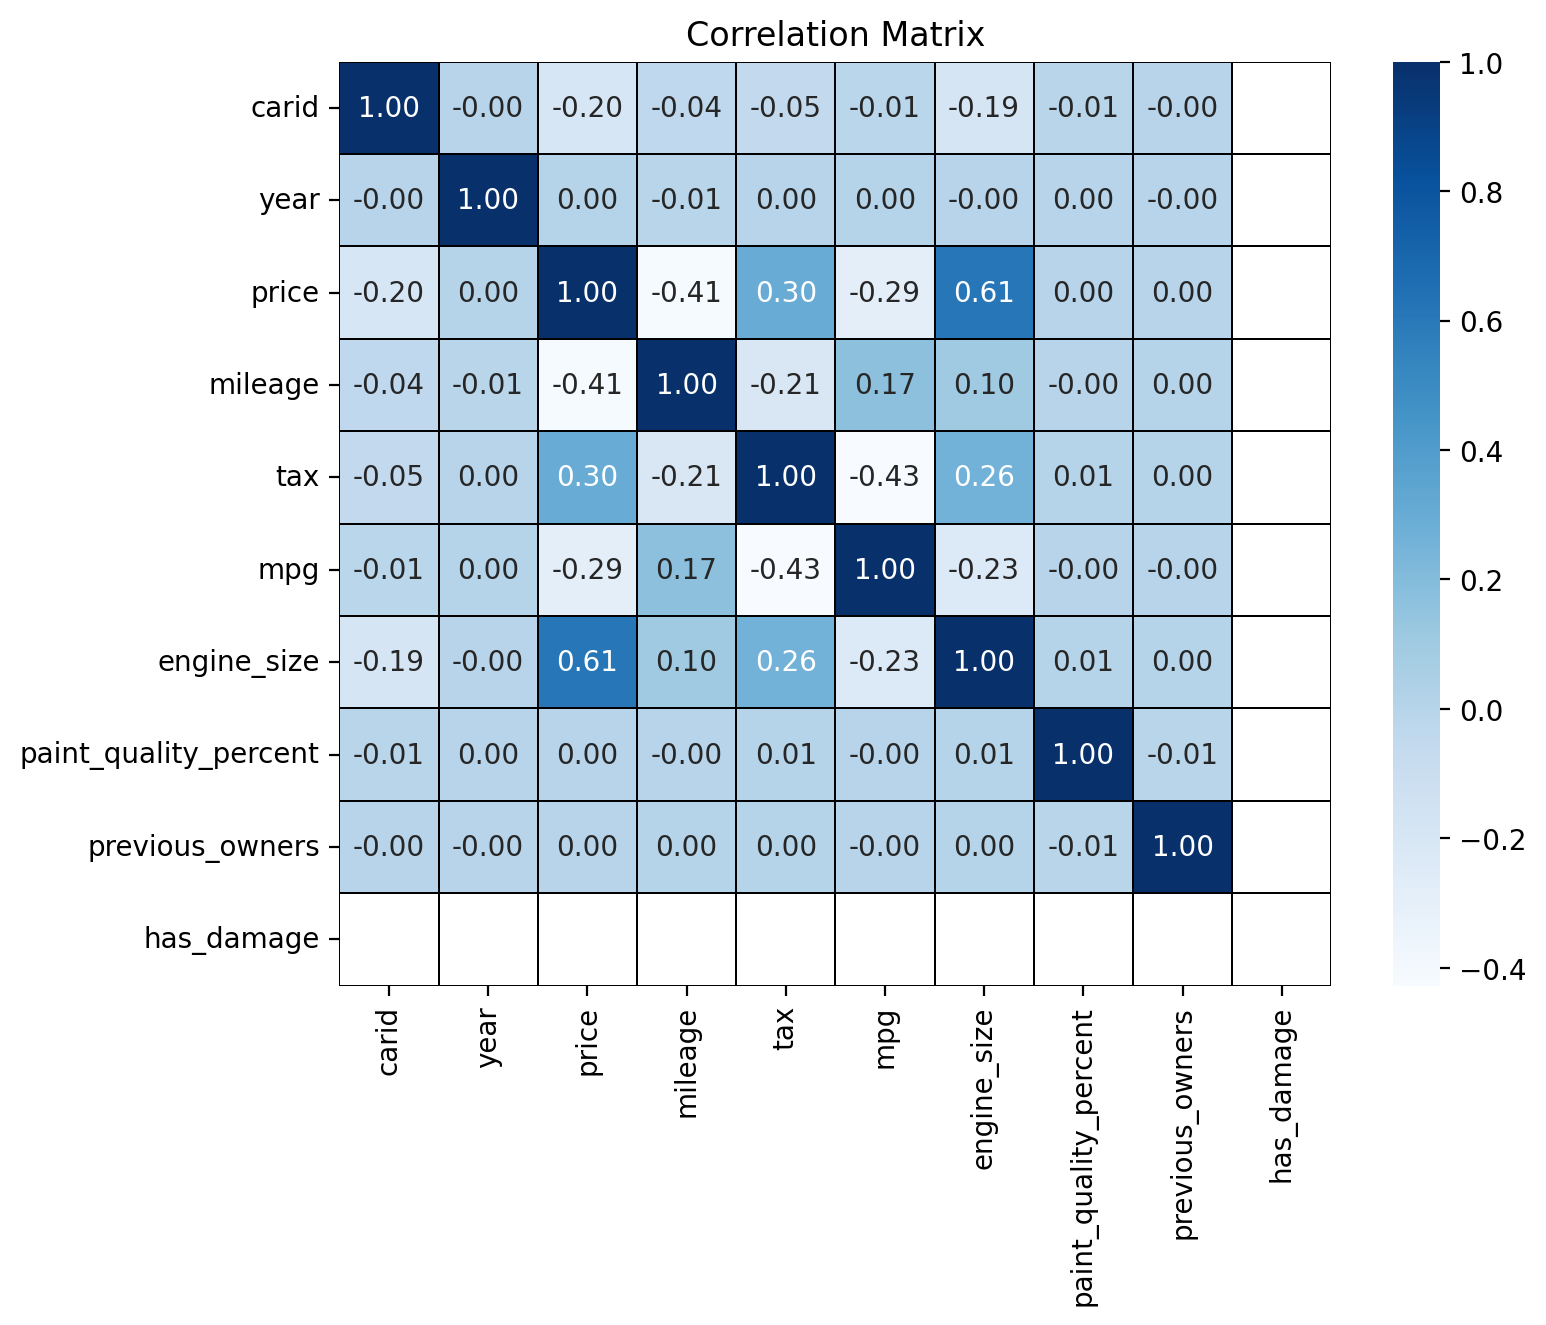

In [25]:
corr = train_cars[metric_features_train].corr()

plt.figure(figsize=(8,6),dpi=200)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linecolor = "black", linewidths=0.01)
plt.title("Correlation Matrix")
plt.show()

## Data Inconsistency Fixes

### Filtering Cars with Maximum Year 2020

In [26]:
year_sup20_train = (train_cars["year"] > 2020).sum()
year_sup20_test = (test_cars["year"] > 2020).sum()

print(f"Train: {year_sup20_train} | Test: {year_sup20_test} rows where year > 2020")

Train: 358 | Test: 180 rows where year > 2020


In [27]:
train_cars = train_cars[train_cars["year"] <=2020].reset_index(drop=True)
test_cars = test_cars[test_cars["year"] <=2020].reset_index(drop=True)

print(f"Train: {train_cars.shape[0]} | Test: {test_cars.shape[0]} rows")

Train: 75615 | Test: 32387 rows


In [28]:
year_inf86_train = ((train_cars['year']<1886) & (train_cars['year']>0)).sum()
year_inf86_test = ((test_cars['year']<1886) & (test_cars['year']>0)).sum()

print(f"Train: {year_inf86_train} | Test: {year_inf86_test} rows with invalid year")

Train: 0 | Test: 0 rows with invalid year


In [29]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75615 entries, 0 to 75614
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   carid                  75615 non-null  int64  
 1   brand                  74102 non-null  object 
 2   model                  74107 non-null  object 
 3   year                   75615 non-null  int64  
 4   price                  75615 non-null  int64  
 5   transmission           74096 non-null  object 
 6   mileage                74157 non-null  float64
 7   fuel_type              74114 non-null  object 
 8   tax                    67748 non-null  float64
 9   mpg                    67725 non-null  float64
 10  engine_size            74105 non-null  float64
 11  paint_quality_percent  74097 non-null  float64
 12  previous_owners        75615 non-null  int64  
 13  has_damage             75615 non-null  int64  
dtypes: float64(5), int64(5), object(4)
memory usage: 8.1+ 

In [30]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32387 entries, 0 to 32386
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   carid                  32387 non-null  int64  
 1   brand                  31740 non-null  object 
 2   model                  31744 non-null  object 
 3   year                   32387 non-null  int64  
 4   transmission           31767 non-null  object 
 5   mileage                31706 non-null  float64
 6   fuel_type              31736 non-null  object 
 7   tax                    29097 non-null  float64
 8   mpg                    29117 non-null  float64
 9   engine_size            31762 non-null  float64
 10  paint_quality_percent  31766 non-null  float64
 11  previous_owners        32387 non-null  int64  
 12  has_damage             32387 non-null  int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 3.2+ MB


### Correcting mpg, engine_size and paint_quality impossible values

In [31]:
mpg_invalid_train = ((train_cars['mpg']<10) | (train_cars['mpg']>120)).sum()
mpg_invalid_test = ((test_cars['mpg']<10) | (test_cars['mpg']>120)).sum()

print(f"Train: {mpg_invalid_train} | Test: {mpg_invalid_test} rows with invalid mpg")

Train: 521 | Test: 239 rows with invalid mpg


In [32]:
train_cars.loc[(train_cars['mpg']<10) | (train_cars['mpg']>120)] = pd.NA
test_cars.loc[(test_cars['mpg']<10) | (test_cars['mpg']>120)] = pd.NA

In [33]:
mpg_invalid_train = ((train_cars['mpg']<10) | (train_cars['mpg']>120)).sum()
mpg_invalid_test = ((test_cars['mpg']<10) | (test_cars['mpg']>120)).sum()

print(f"Train: {mpg_invalid_train} | Test: {mpg_invalid_test} rows with invalid mpg")

Train: 0 | Test: 0 rows with invalid mpg


In [34]:
train_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75615 entries, 0 to 75614
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   carid                  75094 non-null  float64
 1   brand                  73590 non-null  object 
 2   model                  73593 non-null  object 
 3   year                   75094 non-null  float64
 4   price                  75094 non-null  float64
 5   transmission           73584 non-null  object 
 6   mileage                73648 non-null  float64
 7   fuel_type              73602 non-null  object 
 8   tax                    67250 non-null  float64
 9   mpg                    67204 non-null  float64
 10  engine_size            73596 non-null  float64
 11  paint_quality_percent  73580 non-null  float64
 12  previous_owners        75094 non-null  float64
 13  has_damage             75094 non-null  float64
dtypes: float64(10), object(4)
memory usage: 8.1+ MB


In [35]:
test_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32387 entries, 0 to 32386
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   carid                  32148 non-null  float64
 1   brand                  31504 non-null  object 
 2   model                  31508 non-null  object 
 3   year                   32148 non-null  float64
 4   transmission           31530 non-null  object 
 5   mileage                31471 non-null  float64
 6   fuel_type              31502 non-null  object 
 7   tax                    28864 non-null  float64
 8   mpg                    28878 non-null  float64
 9   engine_size            31533 non-null  float64
 10  paint_quality_percent  31533 non-null  float64
 11  previous_owners        32148 non-null  float64
 12  has_damage             32148 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.2+ MB


In [36]:
train_cars[train_cars['engine_size'] == 0]

,carid,brand,model,year,price,transmission,mileage,fuel_type,tax,mpg,engine_size,paint_quality_percent,previous_owners,has_damage
63,30317.0,Ford,NaN,2019.0,9999.0,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
755,21935.0,Ford,KA,2018.0,8444.0,Manual,17000.0,Petrol,145.0,57.7,0.0,51.0,0.0,0.0
1031,9518.0,BMW,2 Series,2015.0,14700.0,Automatic,32882.0,Diesel,125.0,60.1,0.0,55.0,0.0,0.0
1049,32528.0,Hyundai,Tucson,2016.0,13800.0,Manual,27311.0,Diesel,30.0,61.7,0.0,73.0,1.0,0.0
1509,33804.0,Hyundai,Tucson,2019.0,15000.0,Manual,22397.0,Petrol,150.0,34.9,0.0,54.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74114,26630.0,Ford,Fiesta,2018.0,11463.0,NaN,18000.0,Petro,145.0,65.7,0.0,82.0,0.0,0.0
74811,20128.0,Ford,Focus,2018.0,18389.0,Manual,19000.0,Petrol,NaN,NaN,0.0,48.0,2.0,0.0
75044,47605.0,Skoda,Fabia,2018.0,11500.0,Manual,10720.0,Petrol,150.0,64.2,0.0,84.0,4.0,0.0
75048,33307.0,Hyundai,I10,2018.0,8500.0,Manual,12948.0,Petrol,145.0,60.1,0.0,46.0,2.0,0.0


In [37]:
train_cars.loc[(train_cars['engine_size']<0.1)] = pd.NA
test_cars.loc[(test_cars['engine_size']<0.1)] = pd.NA

train_cars.isna().sum()

carid                     680
brand                    2180
model                    2178
year                      680
price                     680
transmission             2185
mileage                  2125
fuel_type                2172
tax                      8513
mpg                      8561
engine_size              2178
paint_quality_percent    2192
previous_owners           680
has_damage                680
dtype: int64

In [38]:
train_cars.loc[(train_cars['paint_quality_percent']>100)] = pd.NA
test_cars.loc[(test_cars['paint_quality_percent']>100)] = pd.NA

train_cars.isna().sum()

carid                    1041
brand                    2534
model                    2530
year                     1041
price                    1041
transmission             2540
mileage                  2477
fuel_type                2525
tax                      8833
mpg                      8875
engine_size              2534
paint_quality_percent    2553
previous_owners          1041
has_damage               1041
dtype: int64

### String Cleaning 

In [39]:
train_cars['brand'].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', <NA>, 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel',
       'pel', 'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda',
       'FORD', 'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford',
       'TOYOTA', 'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI',
       'kod', 'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or',
       'UDI', 'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES',
       'ercede', 'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda',
       'skod', 'toyot'], dtype=object)

In [40]:
train_cars['transmission'].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', <NA>, 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'Other', 'automati', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [41]:
train_cars['fuel_type'].unique()

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', <NA>, 'diesel', 'iesel',
       nan, 'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro',
       'HYBRID', 'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'PETRO',
       'hybrid', 'IESEL', 'ybrid', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'Electric',
       'IESE'], dtype=object)

In [42]:
brand_mapping= {
        #ford
        "or":"ford", "for":"ford", "ord":"ford",
        #vw
        "w":"vw", "v":"vw",
        #opel
        "ope":"opel", "pel":"opel", "pe":"opel",
        #mercedes
        "ercedes":"mercedes", "mercede":"mercedes", "ercede":"mercedes",
        #bmw
        "bm":"bmw", "mw":"bmw",
        #audi
        "udi":"audi", "aud":"audi", "ud":"audi",
        #toyota
        "oyota":"toyota", "toyot":"toyota",
        #skoda
        "skod":"skoda", "kod":"skoda", "koda":"skoda",
        #hyundai
        "yundai":"hyundai", "hyunda":"hyundai", "yunda":"hyundai"
}

transmission_mapping= {
    #manual
    "anual":"manual", "manua":"manual", "anua":"manual",
    #semi-auto
    "semi-aut":"semi-auto", "emi-auto":"semi-auto", "emi-aut":"semi-auto",
    #automatic
    "automati":"automatic", "utomatic":"automatic", "utomati":"automatic", "automati":"automatic",
    #unknown
    "unknow":"unknown", "nknown":"unknown", "nknow":"unknown", "nknow":"unknown", 
}

fuel_mapping= {
    #petrol
    "petro":"petrol", "etrol":"petrol", "etro":"petrol", 
    #diesel
    "iesel":"diesel", "diese":"diesel", "iese":"diesel",
    #hybrid
    "hybri":"hybrid", "ybrid":"hybrid", 'ybri': 'hybrid',
    #other
    "othe":"other", "ther":"other"
} 

def string_cleaning(df, non_metric_features):
    df = df.copy()
    
    mappings = {'brand': brand_mapping,'transmission': transmission_mapping,'fuel_type': fuel_mapping}

    df[non_metric_features] = df[non_metric_features].apply(lambda x: x.str.lower().str.replace(' ', ''))
    
    for col, mapping in mappings.items():
        df[col] = df[col].apply(lambda x: mapping.get(x, x))
    
    return df

In [43]:
train_cars = string_cleaning(train_cars, non_metric_features_train)
test_cars = string_cleaning(test_cars, non_metric_features_test)

In [44]:
train_cars['brand'].unique()

array(['vw', 'toyota', 'audi', 'ford', 'bmw', 'skoda', 'opel', 'mercedes',
       'hyundai', nan, <NA>], dtype=object)

In [45]:
train_cars['transmission'].unique()

array(['semi-auto', 'manual', 'automatic', nan, 'unknown', <NA>, 'other'],
      dtype=object)

In [46]:
train_cars['fuel_type'].unique()

array(['petrol', 'diesel', 'hybrid', <NA>, nan, 'other', 'electric'],
      dtype=object)

In [47]:
train_cars['model'] = train_cars['model'].str.title().str.replace(' ', '')

def simple_similarity(a, b):
    prefix = sum(1 for x, y in zip(a, b) if x == y) 
    score = prefix / max(len(a), len(b))
    return score


unique_models = train_cars['model'].dropna().unique()
corrections = {}

for i, val1 in enumerate(unique_models):
    for val2 in unique_models[i + 1:]:
        score = simple_similarity(val1, val2)
        if score > 0.8 and val1 != val2:
            # choose the one that looks more like a proper word
            if " " in val1 and not " " in val2:
                main, wrong = val1, val2
            elif " " in val2 and not " " in val1:
                main, wrong = val2, val1
            else:
                # otherwise, pick the longer one
                main = max(val1, val2, key=len)
                wrong = min(val1, val2, key=len)
            corrections[wrong] = main

# to avoid the replacement of legit models by Clc Class
valid_main_models = [
    'A Class', 'B Class', 'C Class', 'E Class', 'S Class',
    'CLA Class', 'CLS Class', 'GLA Class', 'GLC Class',
    'GLE Class', 'GLS Class', 'CL Class', 'Clc Class'
]

for wrong, right in list(corrections.items()):
    if right == 'Clc Class' and wrong in valid_main_models:
        del corrections[wrong]


train_cars['model'] = train_cars['model'].replace(corrections)


print(" Corrections made:")
for wrong, main in corrections.items():
    print(f"{wrong:20} - {main}")

print("\nUnique models before:", len(unique_models))
print("Unique models after :", train_cars['model'].nunique())




 Corrections made:
Fiest                - Fiesta
2Series              - 2Series
2Serie               - 2Serie
3Series              - 3Series
3Serie               - 3Serie
Octavi               - Octavia
Passa                - Passat
Insigni              - Insignia
Aclas                - Aclass
Aclass               - Aclass
Glcclass             - Glcclass
Glcclas              - Glcclas
Cclass               - Cclass
Cclas                - Cclass
Eclass               - Eclass
Eclas                - Eclass
Mokka                - Mokkax
5Series              - 5Series
5Serie               - 5Serie
4Series              - 4Series
4Serie               - 4Serie
Ecospor              - Ecosport
Tucso                - Tucson
X-Clas               - X-Class
Clclass              - Clclass
Clclas               - Clclass
Shara                - Sharan
Glsclass             - Glsclass
Glsclas              - Glsclass
Crossland            - Crosslandx
Tigua                - Tiguan
Gleclass             - Glecl

In [48]:
rare_models = train_cars['model'].value_counts()
rare_models = rare_models[rare_models < 5]
print("\nRemaining rare models:")
print(rare_models)


Remaining rare models:
model
Urbancruiser    4
K               4
Caddymaxi       4
I2              4
Scal            4
S8              4
S-Ma            4
Sq7             4
Kadjar          3
T               3
Iq              3
Cascada         3
Rapi            3
M6              3
Slclas          3
Kon             3
I80             3
Vectra          3
Verso-S         3
Ix2             3
M               3
Clsclas         3
Tigra           2
Z               2
Rs              2
7Serie          2
Hilu            2
Streetka        2
Sl              1
S5              1
Clcclass        1
Yet             1
Edg             1
Vers            1
A2              1
220             1
Fox             1
8Serie          1
200             1
Ranger          1
Escort          1
Accent          1
Veloste         1
Kami            1
Terracan        1
Name: count, dtype: int64


In [49]:
train_cars["model"].unique()


array(['Golf', 'Yaris', 'Q2', 'Fiesta', '2Series', '3Series', 'A3',
       'Octavia', 'Passat', 'Focus', 'Insignia', 'Aclass', 'Q3', 'Fabia',
       'Ka+', 'Glcclass', 'I30', 'Cclass', 'Polo', 'Eclass', 'Q5', 'Up',
       'C-Hr', 'Mokkax', 'Corsa', 'Astra', 'Tt', '5Series', 'Aygo',
       '4Series', 'Slk', 'Viva', 'T-Roc', 'Ecosport', 'Tucson', <NA>,
       'X-Class', 'Clclass', 'Ix20', 'I20', 'Rapid', 'A1', 'Auris',
       'Sharan', 'Adam', 'X3', nan, 'A8', 'Glsclass', 'B-Max', 'A4',
       'Kona', 'I10', 'S-Max', 'X2', 'Crosslandx', 'Tiguan', 'A5',
       'Gleclass', 'Zafira', 'Ioniq', 'A6', 'Mondeo', 'Yetioutdoor', 'X1',
       'Scala', 'Sclass', '1Series', 'Kamiq', 'Tourneoconnect', 'Q7',
       'Glaclass', 'Kuga', 'Arteon', 'Slclass', 'Santafe', 'Grandlandx',
       'I800', 'Rav4', 'Touran', 'Citigo', 'Focu', 'Roomster', 'Prius',
       'Corolla', 'Bclass', 'Q', 'Kodiaq', 'Vclass', 'Caddymaxilife',
       'Superb', 'Astr', 'Getz', 'Combolife', 'Beetle', 'Galaxy', 'M3',
       'Gtc

In [50]:
model_corrections = {
    # Typos / truncations
    'Astr': 'Astra',
    'Auri': 'Auris',
    'Ayg': 'Aygo',
    'Ada': 'Adam',
    'Agila': 'Agila',
    'B-Ma': 'B-max',
    'C-Ma': 'C-Max',
    'S-Ma': 'S-Max',
    'Edg': 'Edge',
    'Fabi': 'Fabia',
    'Focu': 'Focus',
    'Gol': 'Golf',
    'GleClas': 'GleClass',
    'GlcClas': 'GlcClass',
    'ClsClas': 'ClsClass',
    'GlaClas': 'GlaClass',
    'SlClas': 'SlClass',
    'Mokk': 'Mokka',
    'Kug': 'Kuga',
    'Karo': 'Karoq',
    'Kami': 'Kamiq',
    'Kon': 'Kona',
    'Pol': 'Polo',
    'Rapi': 'Rapid',
    'Yari': 'Yaris',
    'Yet': 'Yeti',
    'Vers': 'Verso',
    'Ayg': 'Aygo',
    'Auri': 'Auris',
    'I80': 'I800',
    'I1': 'I10',
    'I2': 'I20',
    'Ix2': 'Ix20',
    'Ioni': 'Ioniq',
    'Veloste': 'Veloster',
    'T-Ro': 'T-Roc',
    'Cc': 'PassatCc',
    'S-Ma': 'S-Max',
    'I80': 'I800',
    'M': np.nan,
    'Q': np.nan,
    'A': np.nan,
    'U': 'Up',
    'K': np.nan,
    'Cors': 'Corsa',
    'Focu': 'Focus',
    'Viv': 'Vivaro',
    'Rav': 'Rav4',
    'Scal': 'Scala',
    'T': np.nan,
    'Sl' : 'SlClass',
    'I' : np.nan
}
train_cars["model"] = train_cars["model"].replace(model_corrections)


In [51]:
train_cars["model"].nunique()


206

#### Outlier Detection

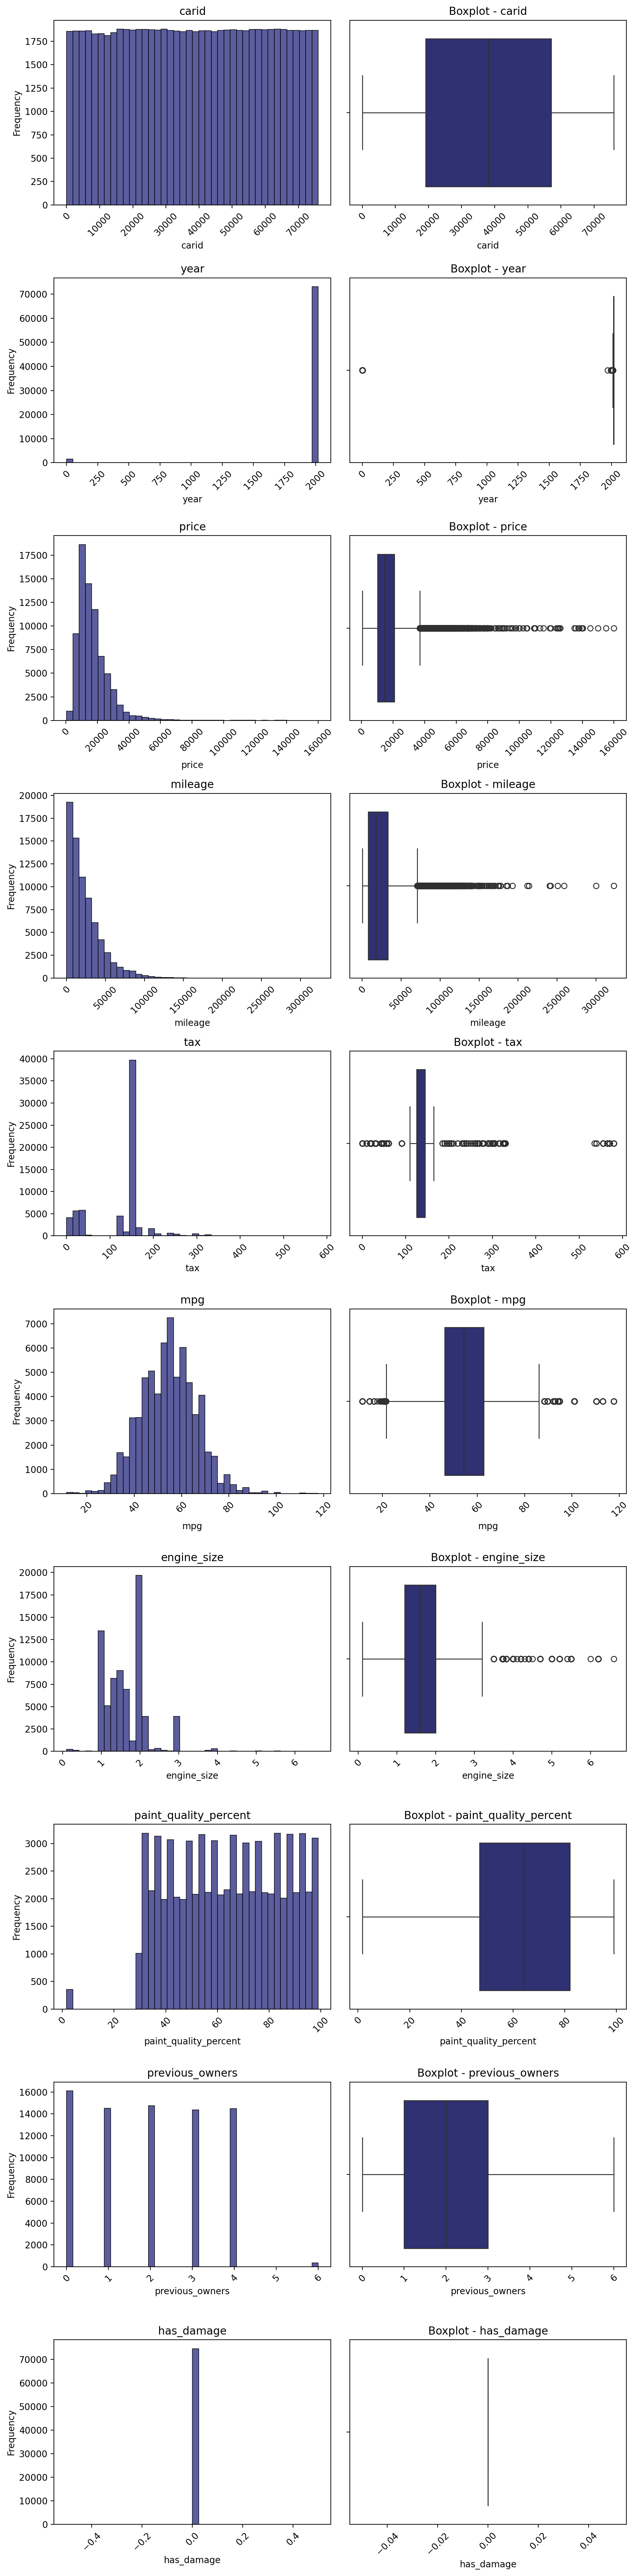

In [52]:
n_rows_subplot = len(metric_features_train)
n_cols_subplot = 2

fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(10, 4 * n_rows_subplot), dpi=200)

for i, col in enumerate(metric_features_train):    
    sns.histplot(train_cars[col], kde=False, bins=40, color="#24277D", ax=axes[i][0])
    axes[i][0].set_title(f"{col}")
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel("Frequency")
    axes[i][0].tick_params(axis="x", rotation=45)

    
    sns.boxplot(x=train_cars[col], color="#24277D", ax=axes[i][1])
    axes[i][1].set_title(f"Boxplot - {col}")
    axes[i][1].set_xlabel(col)
    axes[i][1].set_ylabel("")
    axes[i][1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

In [53]:
def outliers_dataframe(df, numeric_cols):    
    outliers_df = pd.DataFrame(index=df.index)
    pct_outliers = pd.Series(index=numeric_cols, dtype=float)

    for col in numeric_cols:
        data = df[col]
        Q1 = np.percentile(data, 25)
        Q3 = np.percentile(data, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Colocar NaN se não for outlier
        outliers_df[col] = data.where((data < lower) | (data > upper), np.nan)
        
        # Percentagem de outliers
        pct_outliers[col] = outliers_df[col].count() / len(df) * 100

    return outliers_df, pct_outliers

In [54]:
df_outliers_train, pct_outliers_train = outliers_dataframe(train_cars, metric_features_train)
print(pct_outliers_train)  

carid                    0.0
year                     0.0
price                    0.0
mileage                  0.0
tax                      0.0
mpg                      0.0
engine_size              0.0
paint_quality_percent    0.0
previous_owners          0.0
has_damage               0.0
dtype: float64


In [55]:
df_outliers_train.describe().T

,count,mean,std,min,25%,50%,75%,max
carid,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mpg,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_size,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paint_quality_percent,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_owners,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_damage,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Resolving NAs

### Brand Train

In [56]:
print("before:")
print(train_cars['brand'].isna().sum())

model_to_brand = (
    train_cars.dropna(subset=['brand', 'model'])
    .groupby('model')['brand']
    .agg(lambda x: x.mode()[0])  
    .to_dict()
)
mask_brand_missing = train_cars['brand'].isna() & train_cars['model'].notna()
train_cars.loc[mask_brand_missing, 'brand'] = train_cars.loc[mask_brand_missing, 'model'].map(model_to_brand)

print("\nMissing values AFTER filling:")
print(train_cars['brand'].isna().sum())


before:
2534

Missing values AFTER filling:
1080


### Brand Test

In [57]:
print("before:")
print(test_cars['brand'].isna().sum())

model_to_brand = (
    test_cars.dropna(subset=['brand', 'model'])
    .groupby('model')['brand']
    .agg(lambda x: x.mode()[0]) 
    .to_dict()
)
mask_brand_missing = test_cars['brand'].isna() & test_cars['model'].notna()
test_cars.loc[mask_brand_missing, 'brand'] = test_cars.loc[mask_brand_missing, 'model'].map(model_to_brand)

print("\nMissing values AFTER filling:")
print(test_cars['brand'].isna().sum())


before:
1125

Missing values AFTER filling:
499


### Model Train

In [58]:
#Getting model based on brand, mpg, enginesize

print("Missing counts BEFORE filling:")
print(train_cars[['brand', 'model']].isna().sum())

def get_mode(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else np.nan

group1 = train_cars.groupby(['brand', 'year', 'engine_size', 'mpg'])['model'].transform(get_mode)
train_cars['model'] = train_cars['model'].fillna(group1)

group2 = train_cars.groupby(['brand', 'engine_size'])['model'].transform(get_mode)
train_cars['model'] = train_cars['model'].fillna(group2)

print("\nMissing counts AFTER filling:")
print(train_cars[['brand', 'model']].isna().sum())

filled_examples = train_cars.loc[train_cars['model'].notna()].sample(10, random_state=42)
print("\nSample of inferred models:")
print(filled_examples[['brand', 'model', 'year', 'engine_size']])




Missing counts BEFORE filling:
brand    1080
model    2681
dtype: int64

Missing counts AFTER filling:
brand    1080
model    1109
dtype: int64

Sample of inferred models:
          brand     model    year  engine_size
34286        vw    Passat  2019.0     2.000000
27611      ford     Focus  2018.0     1.000000
37468       bmw        X1  2017.0     2.000000
27941      audi        Q3  2017.0     1.400000
2230       audi        Tt  2015.0     3.739235
36593      ford      Kuga  2017.0     2.000000
73022      ford     Focus  2017.0     1.000000
50262  mercedes    Aclass  2019.0     1.300000
53680  mercedes  Glaclass  2019.0     1.600000
31761      ford     Focus  2018.0     1.500000


### Model Test

In [59]:
print("Missing counts BEFORE filling:")
print(test_cars[['brand', 'model']].isna().sum())

def get_mode(series):
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else np.nan

group1 = test_cars.groupby(['brand', 'year', 'engine_size', 'mpg'])['model'].transform(get_mode)
test_cars['model'] = test_cars['model'].fillna(group1)

group2 = test_cars.groupby(['brand', 'engine_size'])['model'].transform(get_mode)
test_cars['model'] = test_cars['model'].fillna(group2)

print("\nMissing counts AFTER filling:")
print(test_cars[['brand', 'model']].isna().sum())

filled_examples = test_cars.loc[test_cars['model'].notna()].sample(10, random_state=42)
print("\nSample of inferred models:")
print(filled_examples[['brand', 'model', 'year', 'engine_size']])

Missing counts BEFORE filling:
brand     499
model    1117
dtype: int64

Missing counts AFTER filling:
brand    499
model    503
dtype: int64

Sample of inferred models:
          brand     model    year  engine_size
12012        vw    tiguan  2019.0          2.0
18064       bmw   1series  2015.0          2.0
27207  mercedes  clsclass  2018.0          2.1
19705  mercedes    cclass  2019.0          1.5
26101      audi        q7  2017.0          4.0
21410      ford     focus  2019.0          1.0
15188    toyota      aygo  2019.0          1.0
12347  mercedes    cclass  2019.0          1.5
12371     skoda     fabia  2019.0          1.0
12303      opel     mokka  2016.0          1.4


In [60]:
missing_models = train_cars[train_cars['model'].isna()]
print(f"Train: Still missing models: {len(missing_models)}")
print(missing_models[['brand', 'year', 'engine_size', 'mpg']].duplicated().value_counts())

missing_models = test_cars[test_cars['model'].isna()]
print(f"Test: Still missing models: {len(missing_models)}")
print(missing_models[['brand', 'year', 'engine_size', 'mpg']].duplicated().value_counts())

Train: Still missing models: 1109
True     1042
False      67
Name: count, dtype: int64
Test: Still missing models: 503
True     483
False     20
Name: count, dtype: int64


In [61]:
all_na = train_cars[['brand', 'year', 'engine_size', 'mpg']].isna().all(axis=1)

train_cars = train_cars[~all_na].reset_index(drop=True)

train_cars.isna().sum()


carid                       0
brand                      39
model                      68
year                        0
price                       0
transmission             1499
mileage                  1436
fuel_type                1484
tax                      7792
mpg                      7834
engine_size              1493
paint_quality_percent    1512
previous_owners             0
has_damage                  0
dtype: int64

In [62]:
all_na = test_cars[['brand', 'year', 'engine_size', 'mpg']].isna().all(axis=1)

test_cars = test_cars[~all_na].reset_index(drop=True)

test_cars.isna().sum()

carid                       0
brand                      16
model                      20
year                        0
transmission              611
mileage                   672
fuel_type                 641
tax                      3258
mpg                      3251
engine_size               613
paint_quality_percent     614
previous_owners             0
has_damage                  0
dtype: int64

In [63]:
train_cars = train_cars.dropna(subset=['model']).reset_index(drop=True)
test_cars = test_cars.dropna(subset=['model']).reset_index(drop=True)

In [64]:
train_cars

,carid,brand,model,year,price,transmission,mileage,fuel_type,tax,mpg,engine_size,paint_quality_percent,previous_owners,has_damage
0,69512.0,vw,Golf,2016.0,22290.0,semi-auto,28421.0,petrol,NaN,11.417268,2.0,63.0,4.0,0.0
1,53000.0,toyota,Yaris,2019.0,13790.0,manual,4589.0,petrol,145.0,47.900000,1.5,50.0,1.0,0.0
2,6366.0,audi,Q2,2019.0,24990.0,semi-auto,3624.0,petrol,145.0,40.900000,1.5,56.0,4.0,0.0
3,29021.0,ford,Fiesta,2018.0,12500.0,manual,9102.0,petrol,145.0,65.700000,1.0,50.0,2.0,0.0
4,10062.0,bmw,2Series,2019.0,22995.0,manual,1000.0,petrol,145.0,42.800000,1.5,97.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74501,37194.0,mercedes,Cclass,2015.0,13498.0,manual,14480.0,petrol,125.0,53.300000,2.0,78.0,0.0,0.0
74502,6265.0,audi,Q3,2013.0,12495.0,semi-auto,52134.0,diesel,200.0,47.900000,2.0,38.0,2.0,0.0
74503,54886.0,toyota,Aygo,2017.0,8399.0,automatic,11304.0,petrol,145.0,67.000000,1.0,57.0,3.0,0.0
74504,860.0,audi,Q3,2015.0,12990.0,manual,69072.0,diesel,125.0,60.100000,2.0,74.0,2.0,0.0


In [65]:
import numpy as np

def replace_invalid(data, column, invalid_values):
    data[column] = data[column].replace(invalid_values, np.nan)
    return data

def fill_mode(data, column, groupby_cols):
    def get_mode(s):
        m = s.mode()
        return m.iloc[0] if not m.empty else np.nan
    data[column] = data[column].fillna(data.groupby(groupby_cols)[column].transform(get_mode))
    return data

def fill_median(data, column, groupby_cols):
    data[column] = data[column].fillna(data.groupby(groupby_cols)[column].transform('median'))
    return data

def fill_average(data, column, groupby_cols):
    data[column] = data[column].fillna(data.groupby(groupby_cols)[column].transform('mean'))
    return data

def clean_dataset(data):
    # Year
    data = replace_invalid(data, 'year', [0])
    if 'price' in data.columns: 
        data = fill_mode(data, 'year', ['model','price'])
    data = fill_median(data, 'year', ['model'])
    
    # Transmission
    data = replace_invalid(data, 'transmission', ['other', 'NaN'])
    data = fill_mode(data, 'transmission', ['model'])
    
    # Mileage
    if 'price' in data.columns: 
        data = fill_median(data, 'mileage', ['model','year','price'])
    data = fill_median(data, 'mileage', ['model','year'])
    data = data.dropna(subset=['mileage']).reset_index(drop=True)
    
    # Fuel type
    data = fill_mode(data, 'fuel_type', ['model'])
    
    # Engine size
    data = fill_median(data, 'engine_size', ['model','mpg'])
    data = fill_median(data, 'engine_size', ['model'])
    
    # MPG
    data = fill_median(data, 'mpg', ['model','engine_size'])
    data = fill_median(data, 'mpg', ['model'])
    
    # Tax
    data = fill_median(data, 'tax', ['engine_size','mpg','year','fuel_type'])
    data = fill_median(data, 'tax', ['engine_size','mpg','fuel_type'])
    data = fill_median(data, 'tax', ['engine_size','fuel_type'])

    # Paint Quality
    if 'price' in data.columns: 
        data = fill_average(data, 'paint_quality_percent', ['year', 'price', 'mileage'])
        data = fill_average(data, 'paint_quality_percent', ['year', 'price'])
        data = fill_average(data, 'paint_quality_percent', ['year'])
    else:
        data = fill_average(data, 'paint_quality_percent', ['year', 'mileage'])
        data = fill_average(data, 'paint_quality_percent', ['year'])

    critical_columns = ['year', 'mileage', 'fuel_type', 'engine_size', 'mpg', 'tax', 'transmission']
    data = data.dropna(subset=[col for col in critical_columns if col in data.columns]).reset_index(drop=True)
    
    return data



In [66]:
train_cars = clean_dataset(train_cars)
test_cars = clean_dataset(test_cars)

# Conferir missing values
print(train_cars.isna().sum())
print(test_cars.isna().sum())

carid                    0
brand                    0
model                    0
year                     0
price                    0
transmission             0
mileage                  0
fuel_type                0
tax                      0
mpg                      0
engine_size              0
paint_quality_percent    0
previous_owners          0
has_damage               0
dtype: int64
carid                    0
brand                    1
model                    0
year                     0
transmission             0
mileage                  0
fuel_type                0
tax                      0
mpg                      0
engine_size              0
paint_quality_percent    0
previous_owners          0
has_damage               0
dtype: int64


# Features

## Dealing with Features

### Categorical

In [67]:
def encode_categorical(df, frequencyencoder_cols=['brand','model'], onehotencoder_cols=['transmission','fuel_type']):
    df_encoded = df.copy()
    
    # 1️⃣ Frequency Encoding
    for col in frequencyencoder_cols:
        freq = df_encoded[col].value_counts()
        df_encoded[col + '_freq'] = df_encoded[col].map(freq)
    
    # 2️⃣ One-Hot Encoding
    df_encoded = pd.get_dummies(df_encoded, columns=onehotencoder_cols, drop_first=True)
    
    return df_encoded

# Exemplo de uso
train_encoded = encode_categorical(train_cars)
test_encoded  = encode_categorical(test_cars)


In [68]:
train_encoded

,carid,brand,model,year,price,mileage,tax,mpg,engine_size,paint_quality_percent,...,has_damage,brand_freq,model_freq,transmission_manual,transmission_semi-auto,transmission_unknown,fuel_type_electric,fuel_type_hybrid,fuel_type_other,fuel_type_petrol
0,69512.0,vw,Golf,2016.0,22290.0,28421.0,147.5,11.417268,2.0,63.0,...,0.0,10418,3326,False,True,False,False,False,False,True
1,53000.0,toyota,Yaris,2019.0,13790.0,4589.0,145.0,47.900000,1.5,50.0,...,0.0,4625,1447,True,False,False,False,False,False,True
2,6366.0,audi,Q2,2019.0,24990.0,3624.0,145.0,40.900000,1.5,56.0,...,0.0,7305,546,False,True,False,False,False,False,True
3,29021.0,ford,Fiesta,2018.0,12500.0,9102.0,145.0,65.700000,1.0,50.0,...,0.0,16181,4500,True,False,False,False,False,False,True
4,10062.0,bmw,2Series,2019.0,22995.0,1000.0,145.0,42.800000,1.5,97.0,...,0.0,7256,814,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74487,37194.0,mercedes,Cclass,2015.0,13498.0,14480.0,125.0,53.300000,2.0,78.0,...,0.0,11627,5263,True,False,False,False,False,False,True
74488,6265.0,audi,Q3,2013.0,12495.0,52134.0,200.0,47.900000,2.0,38.0,...,0.0,7305,972,False,True,False,False,False,False,False
74489,54886.0,toyota,Aygo,2017.0,8399.0,11304.0,145.0,67.000000,1.0,57.0,...,0.0,4625,1392,False,False,False,False,False,False,True
74490,860.0,audi,Q3,2015.0,12990.0,69072.0,125.0,60.100000,2.0,74.0,...,0.0,7305,972,True,False,False,False,False,False,False


In [69]:
test_encoded

,carid,brand,model,year,mileage,tax,mpg,engine_size,paint_quality_percent,previous_owners,has_damage,brand_freq,model_freq,transmission_manual,transmission_semi-auto,transmission_unknown,fuel_type_hybrid,fuel_type_other,fuel_type_petrol
0,106581.0,vw,tiguan,2017.0,48190.655673,150.0,38.2,2.0,60.0,2.0,0.0,4463.0,508,False,True,False,False,False,True
1,80886.0,bmw,2series,2016.0,36792.000000,125.0,51.4,1.5,94.0,2.0,0.0,3086.0,320,False,False,False,False,False,True
2,100174.0,opel,grandlandx,2019.0,5533.000000,145.0,44.1,1.2,77.0,1.0,0.0,4029.0,166,True,False,False,False,False,True
3,81376.0,bmw,1series,2019.0,9058.000000,150.0,51.4,2.0,45.0,4.0,0.0,3086.0,544,False,True,False,False,False,False
4,85391.0,ford,fiesta,2018.0,29626.000000,145.0,65.7,1.0,64.0,1.0,0.0,6927.0,1939,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31866,105775.0,vw,tiguan,2017.0,27575.000000,145.0,46.3,1.4,94.0,1.0,0.0,4463.0,508,True,False,False,False,False,True
31867,81363.0,bmw,x2,2020.0,1980.000000,145.0,34.0,2.0,39.0,3.0,0.0,3086.0,86,False,False,False,False,False,True
31868,76833.0,audi,q5,2019.0,8297.000000,145.0,38.2,2.0,88.0,4.0,0.0,3123.0,255,False,True,False,False,False,False
31869,91768.0,mercedes,aclass,2019.0,50755.210230,145.0,28.5,1.3,81.0,1.0,0.0,4977.0,765,True,False,False,False,False,True


## Feature Engeneering

In [70]:
def create_features(df):  
    df = df.copy()

    df["carAge"] = 2020 - df["year"]
    df["recentModel"] = df["recentModel"] = (train_cars["year"] >= 2018).astype(int)

    #eficiencia do motor
    df["mpg_per_engine"] = df["mpg"] / (df["engineSize"] + 1e-5)
    df["carAge_x_mileage"] = df["carAge"] * df["mileage"]

    df["isHybridOrElectric"] = df["fuelType"].isin(["Hybrid", "Electric"]).astype(int)

    return df

###  Data Scaling

In [71]:

scaler = StandardScaler()
train_cars_ss = train_cars.copy()
train_cars_ss[metric_features_test] = scaler.fit_transform(train_cars_ss[metric_features_test])

test_cars[metric_features_test] = scaler.transform(test_cars[metric_features_test])